<a href="https://colab.research.google.com/github/adityatiwari12/MachineLearning-CSIT/blob/main/Cifar100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading modules and dataset
The very first thing to do when we are about to write a code is importing all required modules


In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from keras.datasets import cifar100 # Changed from cifar10 to cifar100
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from keras.models import Sequential, load_model
from keras.callbacks import EarlyStopping

The CIFAR-10 dataset itself can either be downloaded manually from this link or directly through the code (using API).the dataset size itself is around 160 MB. After the code finishes running, the dataset is going to be stored automatically to X_train, y_train, X_test and y_test variables, where the training and testing data itself consist of 50000 and 10000 samples respectively.

In [43]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 295s 2us/step


The code above tells the computer that we are about to display the first 21 images in the dataset which are divided into 10 columns and 5 rows. The figsize argument is used just to define the size of our figure. We can see here that I am going to set the title using set_title() and display the images using imshow().

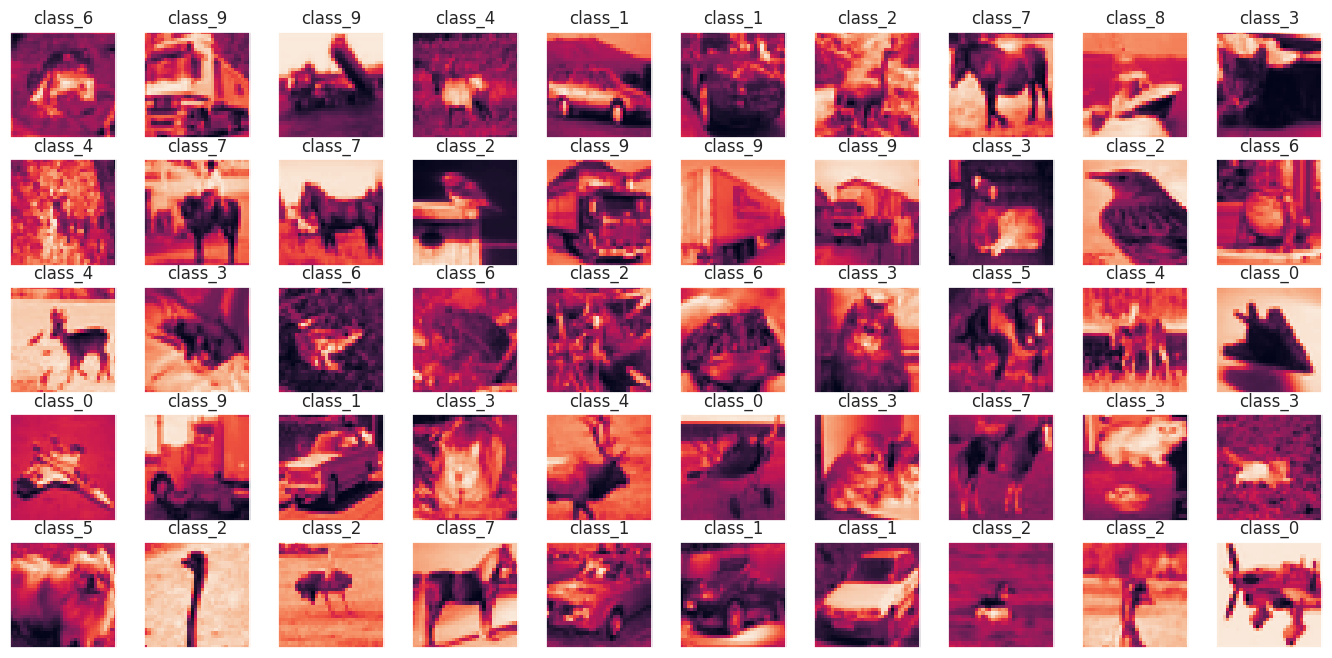

In [41]:
labels = [f"class_{i}" for i in range(100)] # Placeholder labels for CIFAR-100
fig, axes = plt.subplots(ncols=10, nrows=5, figsize=(17, 8))
index = 0
for i in range(5):
    for j in range(10):
        # Get the actual class index from the one-hot encoded y_train
        actual_label_index = np.argmax(y_train[index])
        axes[i,j].set_title(labels[actual_label_index])
        axes[i,j].imshow(X_train[index])
        axes[i,j].get_xaxis().set_visible(False)
        axes[i,j].get_yaxis().set_visible(False)
        index += 1
plt.show()

convert all those images (both train and test data) into grayscale.


In [44]:
X_train = np.array([cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) for image in X_train])
X_test = np.array([cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) for image in X_test])

Now picutre in gray


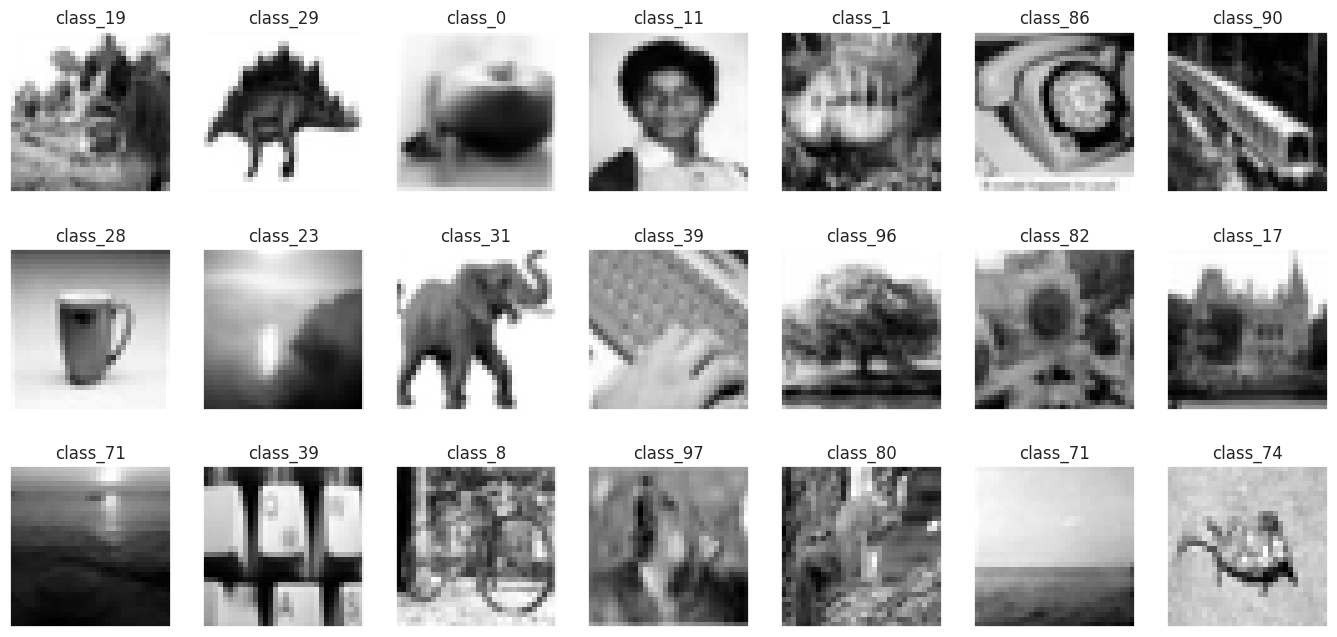

In [45]:
fig, axes = plt.subplots(ncols=7, nrows=3, figsize=(17, 8))
index = 0
for i in range(3):
    for j in range(7):
        axes[i,j].set_title(labels[y_train[index][0]])
        axes[i,j].imshow(X_train[index], cmap='gray')
        axes[i,j].get_xaxis().set_visible(False)
        axes[i,j].get_yaxis().set_visible(False)
        index += 1
plt.show()

normalize array values. We know that by default the brightness of each pixel in any image are represented using a value which ranges between 0 and 255. In order for neural network to work best, we need to convert this value such that it’s going to be in the range between 0 and 1.

In [46]:
X_train  = X_train/255
X_test  = X_test/255

Data preprcessing

In [47]:
# Removed OneHotEncoder usage for consistency with tf.keras.utils.to_categorical

In [48]:
# Removed OneHotEncoder usage for consistency with tf.keras.utils.to_categorical

In [49]:
# Removed OneHotEncoder usage for consistency with tf.keras.utils.to_categorical

the shape of X_train and X_test, the size will be (50000, 32, 32) and (10000, 32, 32) respectively. Well, actually this shape is not acceptable by Conv2D layer that we are going to implement. So, we need to reshape those two arrays using the following code:

In [50]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)


Now our X_train and X_test shapes are going to be (50000, 32, 32, 1) and (10000, 32, 32, 1), where the number 1 in the last position indicates that we are now using only 1 color channel (gray).

In [51]:
input_shape = (X_train.shape[1], X_train.shape[2], 1)

In [52]:
model = Sequential()
model.add(Conv2D(16, (3, 3), activation='relu', strides=(1, 1),
    padding='same', input_shape=input_shape))
model.add(Conv2D(32, (3, 3), activation='relu', strides=(1, 1),
    padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu', strides=(1, 1),
    padding='same'))
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', strides=(1, 1),
    padding='same'))

model.add(Conv2D(32, (3, 3), activation='relu', strides=(1, 1),
    padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu', strides=(1, 1),
    padding='same'))
model.add(MaxPool2D((2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(100, activation='softmax')) # Changed from 10 to 100 for CIFAR-100

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,170,148 (4.46 MB)

 Trainable params: 1,170,148 (4.46 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(loss='categorical_crossentropy',
     optimizer='adam',
     metrics=['acc'])

In [55]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3)

In [56]:
print(X_train.shape)

(50000, 32, 32, 1)


In [57]:
import tensorflow as tf

# Ensure X_train and X_test have the correct shape (N, H, W, 1)
# The model expects grayscale images with a channel dimension.
if len(X_train.shape) == 3: # If shape is (N, H, W), add a channel dimension
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
if len(X_test.shape) == 3: # If shape is (N, H, W), add a channel dimension
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

# Ensure y_train and y_test are one-hot encoded if they aren't already.
num_classes = len(labels) # labels is defined earlier in the notebook

if y_train.shape[-1] == 1:
    y_train = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
if y_test.shape[-1] == 1:
    y_test = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

print(f"X_train shape before fit: {X_train.shape}")
print(f"X_test shape before fit: {X_test.shape}")
print(f"y_train shape before fit: {y_train.shape}")
print(f"y_test shape before fit: {y_test.shape}")

# Explicitly convert to tf.constant to ensure shape is known at graph construction time
X_train_tensor = tf.constant(X_train, dtype=tf.float32)
X_test_tensor = tf.constant(X_test, dtype=tf.float32)
y_train_tensor = tf.constant(y_train, dtype=tf.float32)
y_test_tensor = tf.constant(y_test, dtype=tf.float32)

history = model.fit(X_train_tensor, y_train_tensor, epochs=10
                    , batch_size=32, validation_data=(X_test_tensor, y_test_tensor))

X_train shape before fit: (50000, 32, 32, 1)
X_test shape before fit: (10000, 32, 32, 1)
y_train shape before fit: (50000, 100)
y_test shape before fit: (10000, 100)
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - acc: 0.0091 - loss: 4.6061 - val_acc: 0.0100 - val_loss: 4.6052
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.0087 - loss: 4.6059 - val_acc: 0.0100 - val_loss: 4.6052
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - acc: 0.0089 - loss: 4.6060 - val_acc: 0.0100 - val_loss: 4.6052
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.0089 - loss: 4.6059 - val_acc: 0.0100 - val_loss: 4.6052
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.0092 - loss: 4.6059 - val_acc: 0.0100 - val_loss: 4.6052
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.0092 - loss: 4.6060 - val_acc: 0.0100 - val_loss: 4.6052
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.0089 - loss: 4.6059 - val_acc: 0.0100 - val_l

Test loss: 4.605195045471191 / Test accuracy: 0.009999999776482582


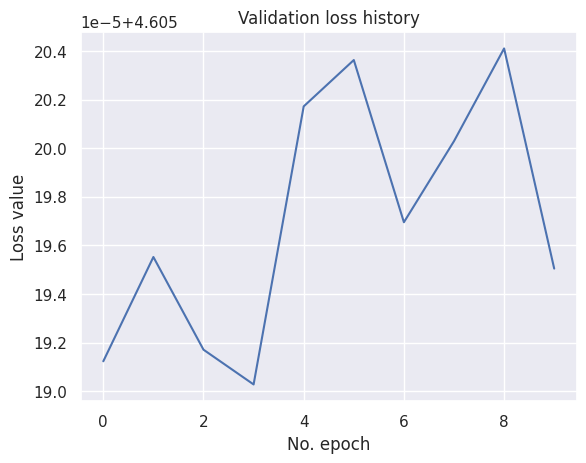

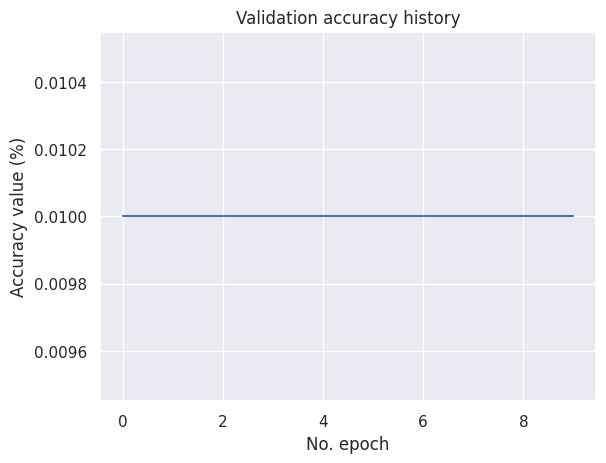

In [58]:
# Generate generalization metrics
score = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {score[0]} / Test accuracy: {score[1]}')

# Visualize history
# Plot history: Loss
plt.plot(history.history['val_loss'])
plt.title('Validation loss history')
plt.ylabel('Loss value')
plt.xlabel('No. epoch')
plt.show()

# Plot history: Accuracy
plt.plot(history.history['val_acc'])
plt.title('Validation accuracy history')
plt.ylabel('Accuracy value (%)')
plt.xlabel('No. epoch')
plt.show()

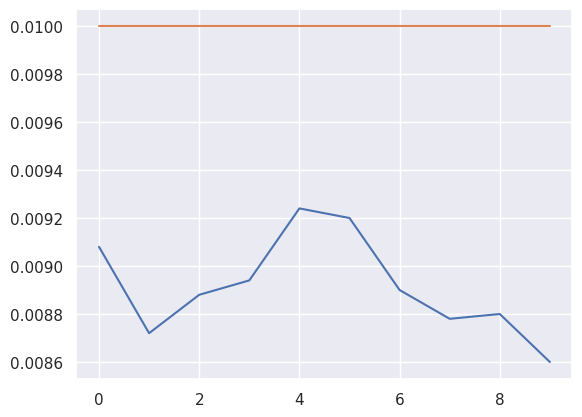

In [59]:
plt.plot(history.history["acc"])
plt.plot(history.history["val_acc"])
plt.show()

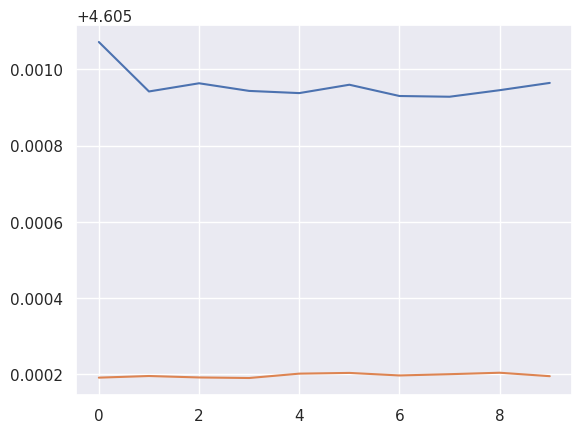

In [60]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.show()

In [61]:
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1) # Convert one-hot predictions to class labels

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [62]:
y_test = np.argmax(y_test, axis=1) # Convert one-hot y_test to class labels

In [63]:
cm = confusion_matrix(y_test, predictions)

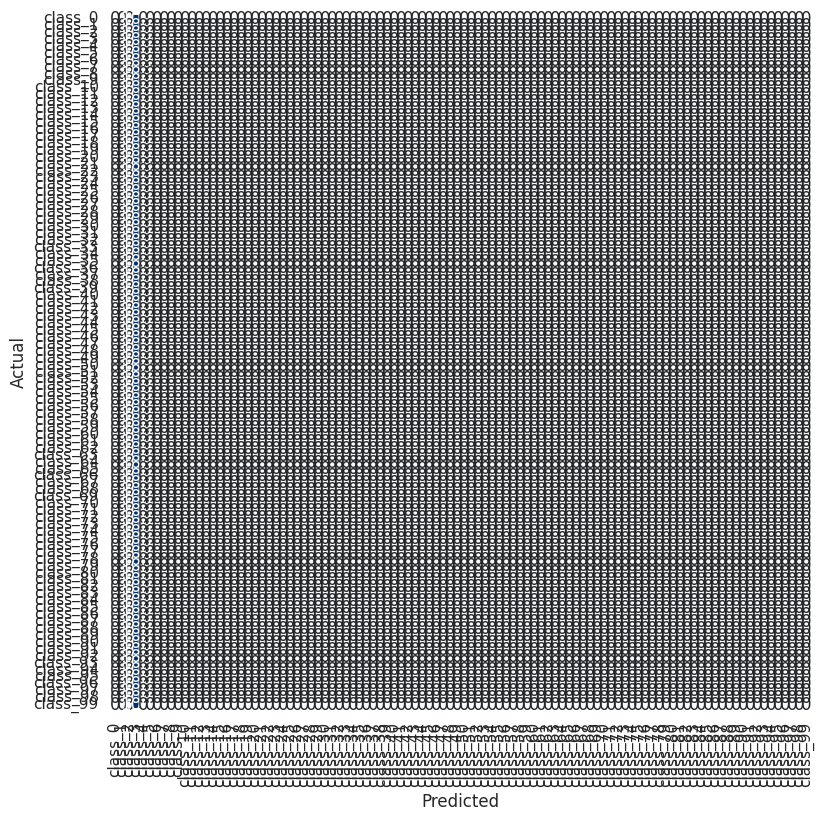

In [64]:
plt.figure(figsize=(9,9))
sns.heatmap(cm, cbar=False, xticklabels=labels, yticklabels=labels, fmt="d", annot=True, cmap=plt.cm.Blues)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [65]:
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

In [66]:
y_test = y_test.astype(int)
predictions = predictions.astype(int)

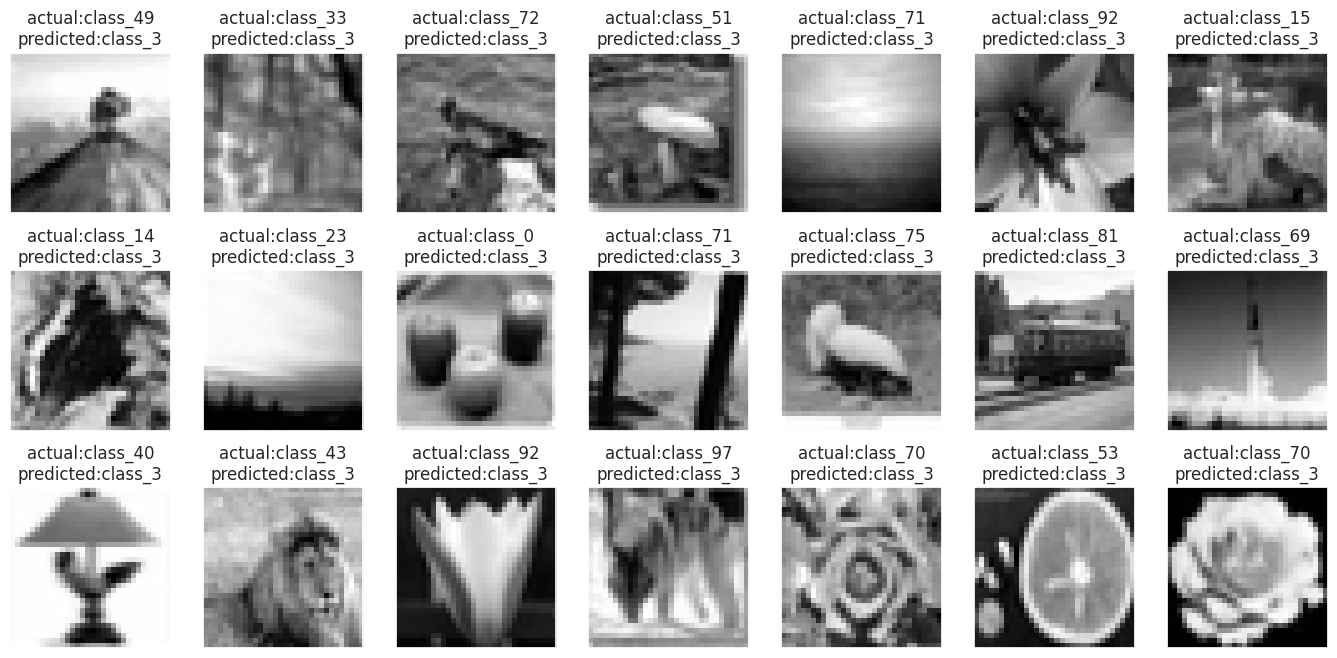

In [67]:
fig, axes = plt.subplots(ncols=7, nrows=3, sharex=False,
    sharey=True, figsize=(17, 8))
index = 0
for i in range(3):
    for j in range(7):
        # y_test and predictions are now 1D arrays of integer class labels
        actual_y_test_label = y_test[index]
        actual_prediction_label = predictions[index]

        axes[i,j].set_title('actual:' + labels[actual_y_test_label] + '\n'
                            + 'predicted:' + labels[actual_prediction_label])
        axes[i,j].imshow(X_test[index], cmap='gray')
        axes[i,j].get_xaxis().set_visible(False)
        axes[i,j].get_yaxis().set_visible(False)
        index += 1
plt.show()